<a href="https://colab.research.google.com/github/sounakmaiti123/Coronary-Artery-Disease-Prediction/blob/main/DSP_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***File_Upload***

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


***Extract_ZIP*** ***File***

In [ ]:
import zipfile
import os

zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted")

Dataset extracted


***Load Images***

In [ ]:
#We are loading the images here and storing them in a numpy array

import cv2     #open cv
import numpy as np
import glob    #to find the files using certain pATTERNS

image_paths = glob.glob("dataset/GAN-Traning Images/*.jpg")

images = []

for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   #shifting to grayscale images
    img = cv2.resize(img, (128,128))          #resizing to fixed size
    img = img/255.0      #normalizing this guy to have similr values (0-1)
    images.append(img)

images = np.array(images)    #shifting to a numpy array

print("Total images:", images.shape)

Total images: (14715, 128, 128)


***Noise Adding***

In [ ]:
def add_gaussian_noise(images):
    noise = np.random.normal(0,0.1,images.shape)  #mean of zero, std of 0.1, basically checking for the batch norm
    noisy = images + noise    #adding noise to images
    noisy = np.clip(noisy,0,1)   #ensures that this shit stays between 0 and 1
    return noisy

noisy_images = add_gaussian_noise(images)

***Apply DSP Filters***----
***Gaussian Filter***

In [ ]:
gaussian_filtered = []    #initializing a list of filitered images

for img in noisy_images:
    filtered = cv2.GaussianBlur(img,(5,5),0)   #applies gaussian file=ter of kernel 5*5
    gaussian_filtered.append(filtered)

gaussian_filtered = np.array(gaussian_filtered)   #finally converting it to a numpy array

***Median Filter  -- This guy preserves the sharp edges while reducing noise and outliers***

In [ ]:
median_filtered = []

for img in noisy_images:
    filtered = cv2.medianBlur((img*255).astype(np.uint8),5)   #appling kernel of 5 and changing type to unsigned interger 8 as understood by opencv
    filtered = filtered/255.0   #again normalizing to reduce overfitting
    median_filtered.append(filtered)

median_filtered = np.array(median_filtered)  #shifing to another numpy array

***Install Tensorflow***

In [ ]:
!pip install tensorflow

***Train Autoencoder (AI Part)***

In [ ]:
#We are importing here the required dependencies

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [ ]:
#THIS SECTION IS LITERALLY THE HEART OF THIS PROJECT
# ENCODING AND DECODING HAPPENS HERE

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(128,128,1)) #Typically receiving images of 128*128

# Encoder (COMPRESSES IT INTO A SMALLER REPRESENTATION)

#The first convolution
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img) #Applies 32 filters, with ReLu activation, giving out 32 feature maps
x = MaxPooling2D((2,2),padding='same')(x)   #We are essentially zooming it, keeping the strongest features to 64*64

#The second convolution
x = Conv2D(16,(3,3),activation='relu',padding='same')(x) #fewer filters, reduced to 16 now

#Off we go with the final encoding compression
encoded = MaxPooling2D((2,2),padding='same')(x)  #reduction from 64 to 32*32

# --------------------------------------------------------------------------------------------------------------------#
#Now we attempt at reconstructing the image

# Decoder

#first convolution
x = Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x) #upscales the image to 64*64 from 32*32 (We are kind of zooming back in)

#second  convolution
x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x) #upscales back to original 128*128

#Conersion back to single grayscale image
decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)  #Why sigmoid and not ReLu? Well, it ensures pixel values between 0 and 1

autoencoder = Model(input_img, decoded) #Model creation

autoencoder.compile(optimizer='adam', loss='mse') #Using adam to optimize

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

***Prepare Data for Training***

In [ ]:
#The final check before training!

import cv2
import numpy as np
import glob

# Re-defining images from previous cells for self-contained execution
image_paths = glob.glob("dataset/GAN-Traning Images/*.jpg")

images_list = []
for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    img = img/255.0
    images_list.append(img)

images = np.array(images_list)

# Re-defining add_gaussian_noise and noisy_images from previous cells
def add_gaussian_noise(images):
    noise = np.random.normal(0,0.1,images.shape)
    noisy = images + noise
    noisy = np.clip(noisy,0,1)
    return noisy

noisy_images = add_gaussian_noise(images)

# Original code from the selected cell

images = images.reshape(-1,128,128,1)

# 128,128 (same img size)
# 1 - adds channel dims
# -1 - automatically calcilates no. of images (3 if it were to be RGB)

noisy_images = noisy_images.reshape(-1,128,128,1)

***Train Model (AutoEncoder)***

In [ ]:
autoencoder.fit(
    noisy_images,
    images,
    epochs=10,   #running 10 times through the entire training set
    batch_size=32,     #minbi-batch size of 32
    validation_split=0.2
)

Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - loss: 0.0156 - val_loss: 0.0048
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - loss: 0.0043 - val_loss: 0.0041
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - loss: 0.0039 - val_loss: 0.0037
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - loss: 0.0037 - val_loss: 0.0035
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - loss: 0.0035 - val_loss: 0.0034
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - loss: 0.0033 - val_loss: 0.0032
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - loss: 0.0032 - val_loss: 0.0031
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - loss: 0.0031 - val_loss: 0.0031
Epoch 9/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 507s 1s/step - loss: 0.0030 - val_loss: 0.0030


***Denoise Images***

In [ ]:
denoised_images = autoencoder.predict(noisy_images)

460/460 ━━━━━━━━━━━━━━━━━━━━ 149s 324ms/step


***Results***

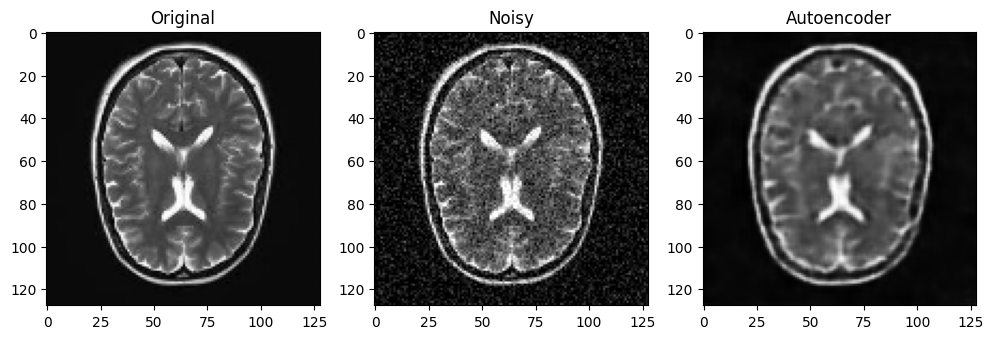

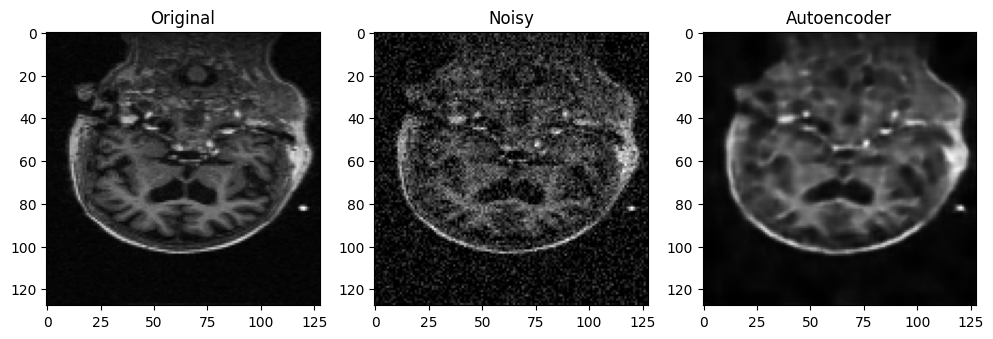

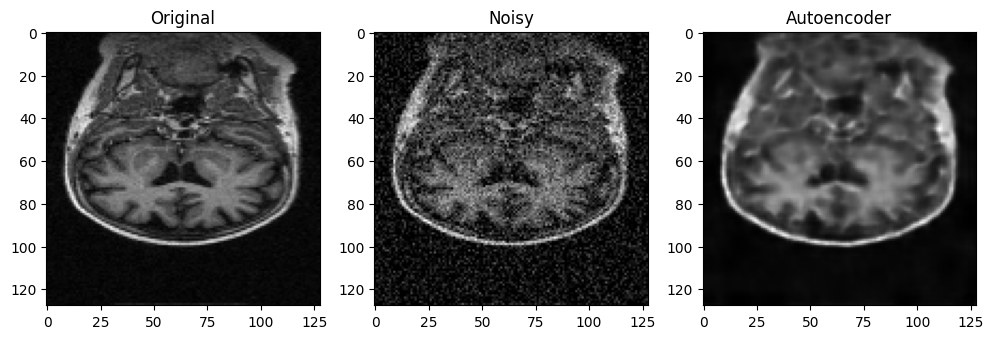

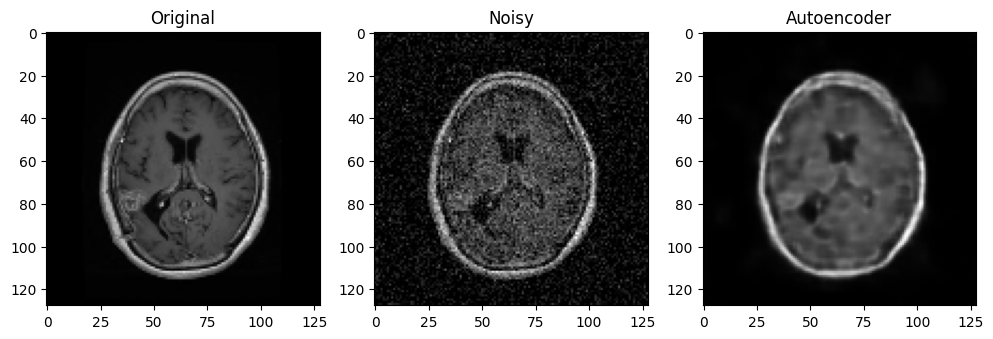

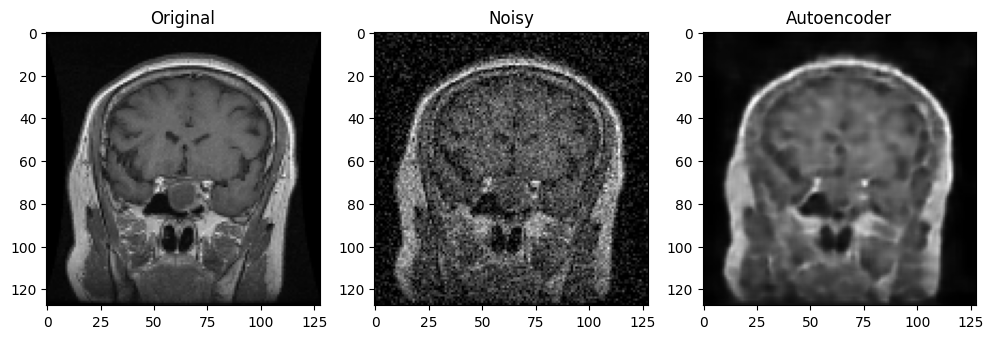

In [ ]:
import matplotlib.pyplot as plt

n = 5

for i in range(n):

    plt.figure(figsize=(12,4))

    # original
    plt.subplot(1,3,1)
    plt.imshow(images[i].reshape(128,128),cmap='gray')
    plt.title("Original")

    # noisy
    plt.subplot(1,3,2)
    plt.imshow(noisy_images[i].reshape(128,128),cmap='gray')
    plt.title("Noisy")

    # denoised
    plt.subplot(1,3,3)
    plt.imshow(denoised_images[i].reshape(128,128),cmap='gray')
    plt.title("Autoencoder")

    plt.show()

***Calculate SSIM (Structural Similarity Index)***

In [ ]:
import cv2
import numpy as np
import glob
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from skimage.metrics import structural_similarity as ssim

# Re-defining images from previous cells for self-contained execution (from cell b4SA_zHntM5n)
image_paths = glob.glob("dataset/GAN-Traning Images/*.jpg")
images_list = []
for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    img = img/255.0
    images_list.append(img)
images = np.array(images_list)

# Re-defining add_gaussian_noise function and noisy_images (from cell XzveRPj4tTga)
def add_gaussian_noise(images_input):
    noise = np.random.normal(0,0.1,images_input.shape)
    noisy = images_input + noise
    noisy = np.clip(noisy,0,1)
    return noisy
noisy_images = add_gaussian_noise(images)

# Reshaping images and noisy_images (from cell xf1bi_yfvwxf)
images = images.reshape(-1,128,128,1)
noisy_images = noisy_images.reshape(-1,128,128,1)

# Re-defining and compiling autoencoder model (from cell 5xa_p7Wlvgj4)
input_img = Input(shape=(128,128,1))
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)
x = Conv2D(16,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)
x = Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Re-training the autoencoder (from cell mImWZlJ1wLPj)
autoencoder.fit(
    noisy_images,
    images,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Suppress training output for cleaner execution
)

# Re-predicting denoised_images (from cell EiQ0Fcq_Dc8V)
denoised_images = autoencoder.predict(noisy_images, verbose=0)

# Original code from the selected cell
scores = []
for i in range(50):
    score = ssim(
        images[i].reshape(128,128),
        denoised_images[i].reshape(128,128),
        data_range=1
    )
    scores.append(score)

print("Average SSIM:", np.mean(scores))

Average SSIM: 0.7479935104969024
